In [1]:
from pathlib import Path
import pandas as pd
import nibabel as nib
import numpy as np

combine_runs_file_path = Path("/Users/clairenastaskin/data/2025-07-08/sub-Forest001_ses-20250708_task-movements_run-004_and_run_005_combined")
run01 = Path("//Users/clairenastaskin/data/2025-07-08/sub-Forest001_ses-20250708_task-movements_run-004")
run02 = Path("/Users/clairenastaskin/data/2025-07-08/sub-Forest001_ses-20250708_task-movements_run-005")
file_name = 'fusi_run_clean.nii.gz' # Upload runs after temporal boxcar smoothing, 

# Load fUSI nifti file and get data into a numpy array
nifti_img1 = nib.load(run01 / file_name)
fusi_data1 = nifti_img1.get_fdata()
print('first run shape:', fusi_data1.shape)

nifti_img2 = nib.load(run02 / file_name)
fusi_data2 = nifti_img2.get_fdata()
print('second run shape:', fusi_data2.shape)

mask_path = next(run01.glob("*mask.nii.gz"))
nifti_mask = nib.load(mask_path)
mask = nifti_mask.get_fdata()
print('mask shape:', mask.shape)

first run shape: (183, 88, 142, 391)
second run shape: (183, 88, 142, 390)
mask shape: (183, 88, 142)


In [2]:
# Load skip frames from numpy files
skip1_frames = np.load(run01 / "registration" / "skip.npy", allow_pickle=True)
skip2_frames = np.load(run02 / "registration" / "skip.npy", allow_pickle=True)

# Handle array that appears as 0-d but contains set
if skip1_frames.shape == () and isinstance(skip1_frames.item(), set):
    skip1_frames = np.array(list(skip1_frames.item()))  # Convert set to array
else:
    skip1_frames = np.array(list(skip1_frames))

# Handle array that appears as 0-d but contains set
if skip2_frames.shape == () and isinstance(skip2_frames.item(), set):
    skip2_frames = np.array(list(skip2_frames.item()))  # Convert set to array
else:
    skip2_frames = np.array(list(skip2_frames))



# Create boolean mask for frames to keep (all indices except skip frames)
mask1 = [t for t in range(fusi_data1.shape[3]) if t not in skip1_frames]
mask2 = [t for t in range(fusi_data2.shape[3]) if t not in skip2_frames]


fusi_data1_masked = fusi_data1[:,:,:,mask1]
fusi_data2_masked = fusi_data2[:,:,:,mask2]

print('first run masked shape:', fusi_data1_masked.shape)
print('second run masked shape:', fusi_data2_masked.shape)


# Convert masked data back to nifti image
fusi_data1_masked_nifti = nib.Nifti1Image(fusi_data1_masked, nifti_img1.affine, nifti_img1.header)
fusi_data2_masked_nifti = nib.Nifti1Image(fusi_data2_masked, nifti_img2.affine, nifti_img2.header)


first run masked shape: (183, 88, 142, 376)
second run masked shape: (183, 88, 142, 368)


In [3]:
import warnings
from nilearn.image import concat_imgs, mean_img, resample_img

# Avoid getting too many warnings due to resampling
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fusi_img = [
        # nifti_img1,  # Use the NIfTI image object directly
        # nifti_img2,  # Use the NIfTI image object directly
        fusi_data1_masked_nifti,  # Use the NIfTI image object directly
        fusi_data2_masked_nifti,  # Use the NIfTI image object directly
    ]
affine, shape = fusi_img[0].affine, fusi_img[0].shape
print("Resampling the second image (this takes time)...")
fusi_img[1] = resample_img(
    fusi_img[1], affine, shape[:3], copy_header=True, force_resample=True
)

print(f"First run shape: {fusi_img[0].shape}")
print(f"Second run shape: {fusi_img[1].shape}")

Resampling the second image (this takes time)...
First run shape: (183, 88, 142, 376)
Second run shape: (183, 88, 142, 368)


In [4]:
mean_image = mean_img(fusi_img, copy_header=True)
print(f"Mean image shape: {mean_image.shape}")

Mean image shape: (183, 88, 142)


In [5]:
# repetition time, in seconds
t_r = run01 / 't_r.npy'
# Sample at the beginning of each acquisition.
slice_time_ref = 0.0
# We use a discrete cosine transform to model signal drifts.
drift_model = "Cosine"
# The cutoff for the drift model is 0.01 Hz.
high_pass = 0.01
# The hemodynamic response function
hrf_model = "spm + derivative"

In [6]:
import numpy as np
import pandas as pd
from numpy import load
from nilearn.glm.first_level import make_first_level_design_matrix

# Load design matrices with recation time taken into account already 
design_matrices = []
design_matrix_1 = load(run01 / 'design_matrix.npz', allow_pickle=True)
design_matrix_2 = load(run02 / 'design_matrix.npz', allow_pickle=True)

# Extract the design matrices and column names from the npz files
dm1 = pd.DataFrame(design_matrix_1['design_matrix'], columns=design_matrix_1['column_names'])
dm2 = pd.DataFrame(design_matrix_2['design_matrix'], columns=design_matrix_2['column_names'])

design_matrices = [dm1, dm2]
for i, dm in enumerate(design_matrices, 1):
    print(f"Design matrix {i} shape: {dm.shape}")

Design matrix 1 shape: (376, 52)
Design matrix 2 shape: (368, 51)


/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_28913/341075645.py:5: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(design_matrices[0], ax=axes[0])
/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_28913/341075645.py:7: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(design_matrices[1], ax=axes[1])
/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_28913/341075645.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


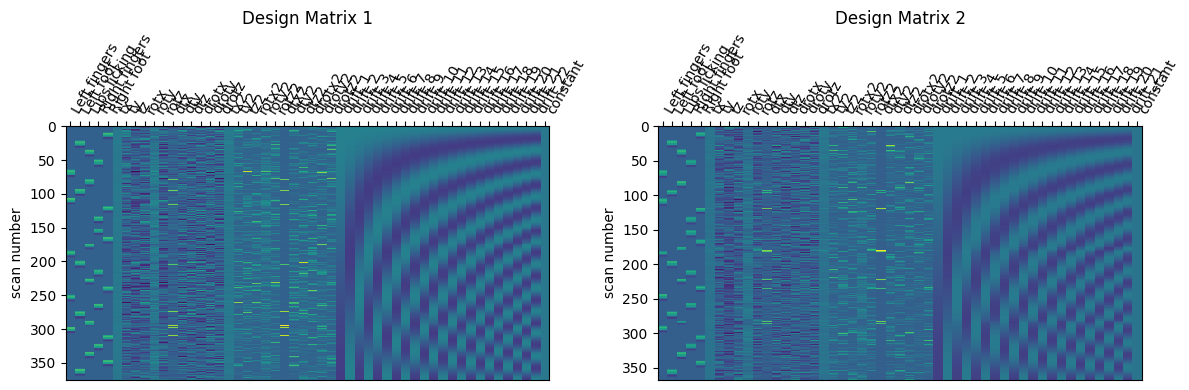

In [7]:
import matplotlib.pyplot as plt
from nilearn.plotting import plot_design_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_design_matrix(design_matrices[0], ax=axes[0])
axes[0].set_title('Design Matrix 1')
plot_design_matrix(design_matrices[1], ax=axes[1]) 
axes[1].set_title('Design Matrix 2')
plt.tight_layout()
fig.show()

In [8]:
##########################################
## Create contrasts for localizer task ##
##########################################

def find_all_localizer_contrasts(design_matrices):
    contrast_list = []
    contrasts = []

    for i in range(len(design_matrices)):
        # Get column names excluding motion parameters and drifts
        contrast = [col for col in design_matrices[i].columns 
                    if not col.startswith(('rot', 'drift')) 
                    and col not in ['constant', 'tx', 'ty', 'tz']]
        contrasts.append(contrast)
        
        # Add unique names to overall contrast list
        contrast_list.extend([c for c in contrast if c not in contrast_list])

    contrast_matrix = np.eye(len(contrast_list))
    contrasts = {
        column: contrast_matrix[i]
        for i, column in enumerate(contrast_list)
    }
    return contrasts
    
contrasts = find_all_localizer_contrasts(design_matrices)
print(contrasts)

{'Left fingers': array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.]), 'Left foot': array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.]), 'Lips licking': array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.]), 'Right fingers': array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.]), 'Right foot': array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.]), 'dtx': array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.]), 'dty': array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.]), 'dtz': array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.]), 'drotx': array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.]), 'droty': array([0., 0., 0., 0

In [9]:
from nilearn import plotting
from nilearn.glm.first_level import FirstLevelModel

print("Fitting a GLM")
# Load TR from run01 and convert to float
t_r = float(np.load(run01 / 't_r.npy'))
print(f"TR loaded: {t_r} seconds")


# fusi_glm = FirstLevelModel(
#     t_r=t_r,
#     minimize_memory=True,
#     mask_img=False,
#     smoothing_fwhm=smoothing_fwhm,
#     standardize=True,
# )

fusi_glm = FirstLevelModel(
        t_r=t_r, minimize_memory=True, hrf_model="glover", drift_model="cosine",
        high_pass=0.01, noise_model="ar1", standardize=True,
        smoothing_fwhm=2, mask_img=nifti_mask)

fusi_glm = fusi_glm.fit(fusi_img, design_matrices=design_matrices)


Fitting a GLM
TR loaded: 2.8169935000000095 seconds


	contrast id: Left fingers


/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_28913/933157126.py:12: UserWarning: One contrast given, assuming it for all 2 runs
  z_map = fusi_glm.compute_contrast(contrast_val, output_type="z_score")
/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/nilearn/glm/contrasts.py:115: UserWarning: t contrasts should be of length P=52, but it has length 20. The rest of the contrast was padded with zeros.
  reg = regression_result[label_].Tcontrast(con_val)
/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/nilearn/glm/contrasts.py:115: UserWarning: t contrasts should be of length P=51, but it has length 20. The rest of the contrast was padded with zeros.
  reg = regression_result[label_].Tcontrast(con_val)


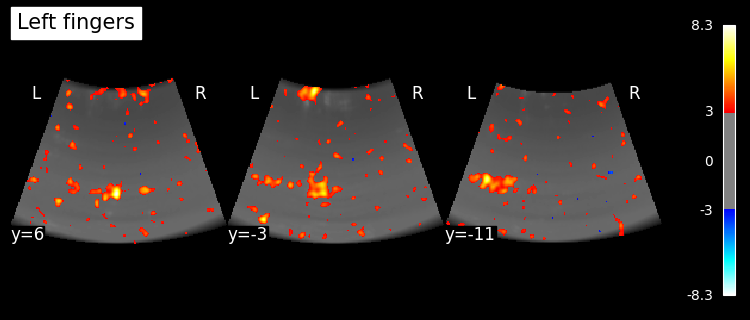

	contrast id: Left foot


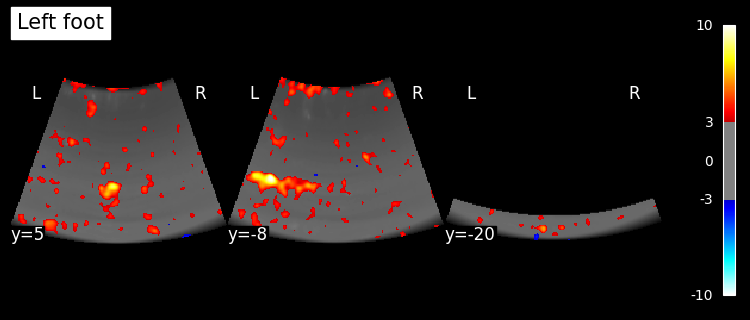

	contrast id: Lips licking


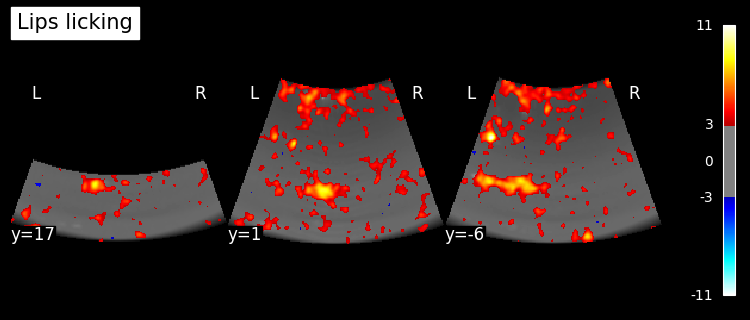

	contrast id: Right fingers


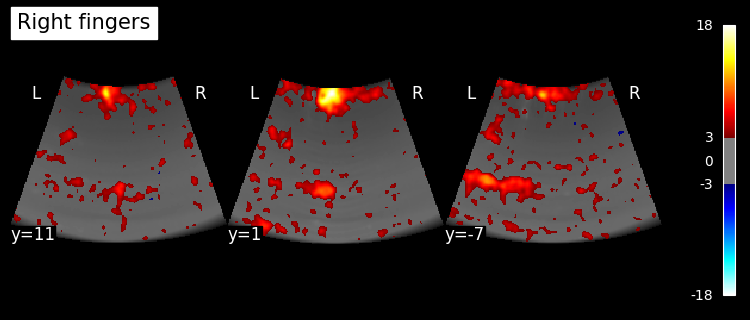

	contrast id: Right foot


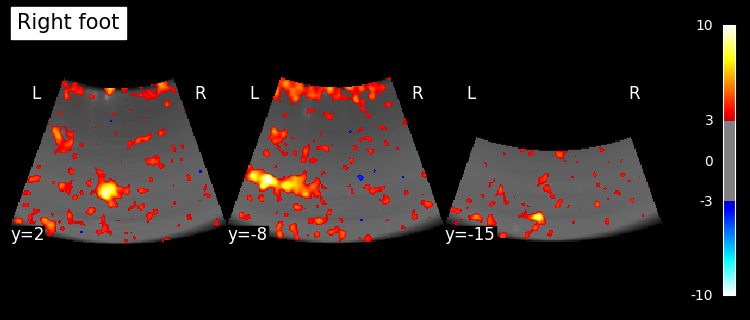

In [10]:
import os

affine_global = nifti_img1.affine

# Iterate on contrasts
for contrast_id, contrast_val in contrasts.items():
    if contrast_id.startswith(("drift_", "tx", "ty", "tz", "rot", "dt", "drot")):
        continue

    print(f"\tcontrast id: {contrast_id}")
    # compute the contrasts
    z_map = fusi_glm.compute_contrast(contrast_val, output_type="z_score")
        # Get the data from z_map and create new NIfTI image
    z_map_data = z_map.get_fdata()
    nii_zmap = nib.Nifti1Image(z_map_data, affine_global)
    # Save the NIfTI zmap to a compressed .nii.gz file in the base_path
    output_path = os.path.join(combine_runs_file_path, f"{contrast_id}_z_map.nii.gz")
    nib.save(nii_zmap, output_path)
    

    plotting.plot_stat_map(
        z_map,
        bg_img=mean_image,
        threshold=3.0,
        display_mode="y",
        cut_coords=3,
        black_bg=True,
        title=contrast_id,
    )
    plotting.show()